# Plug-and-Play Learned Regularization in PET Reconstruction: Integration of DeepInverse with STIR

This notebook demonstrates how learned priors from the DeepInverse library can be integrated into physics-based PET reconstruction workflows using SIRF/STIR and CIL.

The framework combines:

- PET forward models from STIR,
- optimization algorithms from CIL,
- and learned regularization methods from DeepInverse.


## Overview

This notebook contains three Plug-and-Play (PnP) learned reconstruction workflows:

### 1. PnP-PD3O (WCRR)
Variational reconstruction using the PD3O algorithm with a Weakly Convex Ridge Regularizer (WCRR) as an explicit learned prior.

### 2. PnP-SVRG (DRUNet)
Plug-and-Play reconstruction using a DRUNet denoiser within a Stochastic Variance Reduced Gradient (SVRG) optimization loop.

### 3. PnP-HQS (DRUNet)
Plug-and-Play reconstruction using a DRUNet denoiser within a Half Quadratic Splitting (HQS) optimization framework.

## Framework

<div align="center">
<img src="Framework.png" alt="Framework" style="max-width:90%; height:auto;" />
</div>


## Evaluation

The notebook finally performs a comparative evaluation of the following reconstruction methods:

1. **OSMAPOSL**
2. **OSMAPOSL+RDP**
3. **PnP-PD3O (WCRR)**
4. **PnP-SVRG (DRUNet)**
5. **PnP-HQS (DRUNet)**


# Parameters used for each methods

All reconstruction sections below read their hyperparameters from `SELECTED_PARAMETERS`.  


In [1]:
SELECTED_PARAMETERS = {

    "OSMAPOSL": {
        "num_subsets": 4,
        "num_iterations": 100,
    },

    "OSMAPOSL+RDP": {
        "num_subsets": 4,
        "num_iterations": 100,
        "regularization_weight": 0.3,
        "gamma": 2.0,
        "epsilon": 1e-3,
    },

    "PnP-PD3O (WCRR)": {
        "num_iterations": 100,
        "regularization_weight": 0.01,
        "intensity_scale": 0.5,
        "step_size": 0.5,
    },

    "PnP-SVRG (DRUNet)": {
        "num_iterations": 100,
        "step_size": 1.0,
        "denoiser_strength": 3.0 / 255.0,
        "denoiser_blend": 0.15,
    },

    "PnP-HQS (DRUNet)": {
        "num_iterations": 50,
        "regularization_weight": 1e-2,
        "denoiser_strength": 3.0 / 255.0,
    },
}

# Initialize libraries, imports, data paths, and functions

Note:
Install the following libraries if not installed before:
- !pip install torch torchvision torchaudio
- !pip install numpy matplotlib scipy scikit-image
- !pip install deepinv

## Imports

In [2]:
import os
import numpy as np
from numpy.linalg import norm
import matplotlib.pyplot as plt
import sirf.STIR as pet
from sirf.Utilities import examples_data_path
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.parametrize as P
import deepinv as dinv
from deepinv.models import DRUNet, EquivariantDenoiser
from tqdm.notebook import tqdm
from cil.optimisation.algorithms import PD3O, PDHG
from cil.optimisation.functions import KullbackLeibler, IndicatorBox, Function, SVRGFunction
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

## Functions

In [3]:
np.random.seed(42)
torch.manual_seed(42)

msg_red = pet.MessageRedirector("info.txt", "warnings.txt", "errors.txt")
data_path = os.path.join(examples_data_path("PET"), "thorax_single_slice")


def make_cylindrical_fov(image):
    """Apply cylindrical FOV truncation to a SIRF image."""
    trunc = pet.TruncateToCylinderProcessor()
    trunc.apply(image)
    return image


def make_positive(image_array):
    """Set negative voxel values to zero."""
    image_array = image_array.copy()
    image_array[image_array < 0] = 0
    return image_array


def plot_2d_image(idx, vol, title, clims=None, cmap="hot"):
    plt.subplot(*idx)
    plt.imshow(vol, cmap=cmap)
    if clims is not None:
        plt.clim(clims)
    plt.colorbar(shrink=0.4)
    plt.title(title)
    plt.axis("off")


def build_problem(count_scale_factor=2.0, num_tangential_lors=5):
    """Create one shared PET reconstruction problem used by all methods."""
    ground_truth = pet.ImageData(os.path.join(data_path, "emission.hv")) * count_scale_factor
    template = pet.AcquisitionData(os.path.join(data_path, "template_sinogram.hs"))

    acq_model = pet.AcquisitionModelUsingRayTracingMatrix()
    acq_model.set_num_tangential_LORs(num_tangential_lors)
    acq_model.set_up(template, ground_truth)

    clean_data = acq_model.forward(ground_truth)
    acquired_data = clean_data.clone()
    acquired_data.fill(np.random.poisson(clean_data.as_array()).astype(np.float32))

    initial_image = ground_truth.get_uniform_copy(ground_truth.max() * 0.15)
    make_cylindrical_fov(initial_image)

    obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
    obj_fun.set_acquisition_model(acq_model)
    if hasattr(obj_fun, "set_num_subsets"):
        obj_fun.set_num_subsets(1)
    if hasattr(obj_fun, "set_up"):
        obj_fun.set_up(initial_image)

    im_slice = ground_truth.dimensions()[0] // 2
    return ground_truth, acquired_data, acq_model, obj_fun, initial_image, im_slice


def _to_numpy_2d(x, preferred_slice=None):
    if x is None:
        return None
    if hasattr(x, "solution"):
        x = x.solution
    if hasattr(x, "as_array"):
        x = x.as_array()
    if hasattr(x, "detach"):
        x = x.detach().cpu().numpy()

    x = np.asarray(x).astype(np.float32)
    x = np.squeeze(x)

    if x.ndim == 3:
        z = preferred_slice if preferred_slice is not None else x.shape[0] // 2
        return x[z].astype(np.float32)
    if x.ndim == 2:
        return x.astype(np.float32)

    raise ValueError(f"Cannot convert array with shape {x.shape} to 2D image.")


## Simulate noisy PET acquisition data and set the reconstruction problem

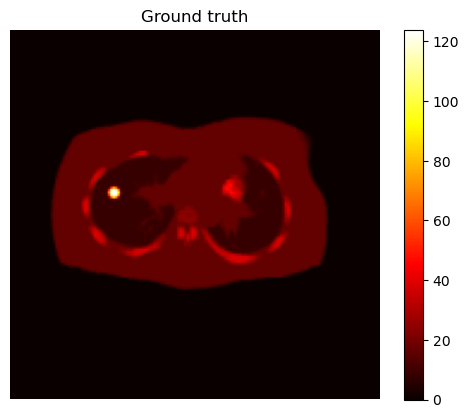

In [4]:
ground_truth, acquired_data, acq_model, obj_fun, initial_image, im_slice = build_problem()

image = ground_truth
x = initial_image.clone()
cmax = ground_truth.max() * 0.6

plt.imshow(ground_truth.as_array()[im_slice, :, :], cmap="hot")
plt.colorbar()
plt.title("Ground truth")
plt.axis("off")
plt.show()

---

# 1. PnP-PD3O (WCRR): variational learned regularization

* This section demonstrates variational PET reconstruction using a learned prior integrated within the SIRF/CIL framework.
* It implements the PD3O (Primal-Dual Three-Operator) optimization algorithm.
* The regularization uses a Weakly Convex Ridge Regularizer (WCRR) with pre-trained weights from the `sirf.contrib.PnP_with_DeepInverse` module.

## Perform baseline OSMAPOSL reconstruction for comparison

In [5]:
params = SELECTED_PARAMETERS["OSMAPOSL"]
num_subsets = params["num_subsets"]
num_subiterations = params["num_iterations"]

osem_obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
osem_obj_fun.set_acquisition_model(acq_model)

osem = pet.OSMAPOSLReconstructor()
osem.set_objective_function(osem_obj_fun)
osem.set_num_subsets(num_subsets)
osem.set_num_subiterations(num_subiterations)

osem_initial = initial_image.clone()

osem.set_current_estimate(osem_initial)
osem.set_up(osem_initial)
osem.process()
osem_recon = osem.get_output()
recon_osmaposl = osem_recon


## Implement WCRR neural network prior and CIL optimization function wrapper

In [6]:
class ZeroMean(nn.Module):
    def forward(self, x): return x - torch.mean(x, dim=(1, 2, 3), keepdim=True)

class WCRR(nn.Module):
    def __init__(self, sigma, weak_convexity, device="cpu", pretrained=None):
        super().__init__()
        nb_channels=[1, 4, 8, 64]
        filter_sizes=[5, 5, 5]
        self.nb_filters = nb_channels[-1]
        self.filter_size = sum(filter_sizes) - len(filter_sizes) + 1
        self.filters = nn.Sequential(*[
            nn.Conv2d(nb_channels[i], nb_channels[i + 1], filter_sizes[i], padding=filter_sizes[i] // 2, bias=False)
            for i in range(len(filter_sizes))
        ])
        P.register_parametrization(self.filters[0], "weight", ZeroMean())
        self.dirac = torch.zeros(1, 1, 2 * self.filter_size - 1, 2 * self.filter_size - 1)
        self.dirac[:, :, self.filter_size - 1, self.filter_size - 1] = 1.0
        self.scaling = nn.Parameter(torch.log(torch.tensor(2.0) / sigma) * torch.ones(1, self.nb_filters, 1, 1))
        self.beta = nn.Parameter(torch.tensor(4.0))
        self.weak_cvx = weak_convexity
        if pretrained: self.load_state_dict(torch.load(pretrained, map_location=device))

    def smooth_l1(self, x): return torch.clip(x**2, 0.0, 1.0) / 2 + torch.clip(torch.abs(x), 1.0) - 1.0
    def grad_smooth_l1(self, x): return torch.clip(x, -1.0, 1.0)
    def get_conv_lip(self):
        impulse = self.filters(self.dirac)
        for filt in reversed(self.filters): impulse = F.conv_transpose2d(impulse, filt.weight, padding=filt.padding)
        return torch.fft.fft2(impulse, s=[256, 256]).abs().max()
    def conv(self, x): return self.filters(x / torch.sqrt(self.get_conv_lip()))
    def grad(self, x):
        g = self.conv(x) * torch.exp(self.scaling)
        g = (self.grad_smooth_l1(torch.exp(self.beta) * g) - self.grad_smooth_l1(g) * self.weak_cvx) * torch.exp(-self.scaling)
        x_out = g / torch.sqrt(self.get_conv_lip())
        for filt in reversed(self.filters): x_out = F.conv_transpose2d(x_out, filt.weight, padding=filt.padding)
        return x_out
    def g(self, x):
        r = self.conv(x) * torch.exp(self.scaling)
        r = (self.smooth_l1(torch.exp(self.beta) * r) * torch.exp(-self.beta) - self.smooth_l1(r) * self.weak_cvx)
        return (r * torch.exp(-2 * self.scaling)).sum(dim=(1, 2, 3))

class WCRRCIL(Function):
    def __init__(self, lamb=0.01, scale=0.5):
        super().__init__()
        self.lamb, self.scale = lamb, scale
        self.model = WCRR(sigma=0.1, weak_convexity=0.0)
        path = os.path.abspath(os.path.join(os.getcwd(), '..', 'Python', 'sirf', 'contrib', 'PnP_with_DeepInverse', 'WCRR_bilevel_JFB_for_CT.pt'))
        weights = torch.load(path, map_location='cpu')
        new_w = {k.replace("regularizer.", ""): v for k, v in weights.items() if k.startswith("regularizer.")}
        self.model.load_state_dict(new_w, strict=False)

    def __call__(self, x):
        t = torch.from_numpy(x.as_array()).float().unsqueeze(0)
        return self.lamb * float(self.model.g(self.scale * t).item()) / self.scale**2

    def gradient(self, x, out=None):
        t = torch.from_numpy(x.as_array()).float().unsqueeze(0)
        grad = self.model.grad(self.scale * t)[0].detach().cpu().numpy()
        if out is None: out = x.get_uniform_copy()
        out.fill(grad * self.lamb / self.scale)
        return make_cylindrical_fov(out)

## Configure and execute the PD3O optimization algorithm

In [7]:
params = SELECTED_PARAMETERS["PnP-PD3O (WCRR)"]
num_iterations = params["num_iterations"]
regularization_weight = params["regularization_weight"]
intensity_scale = params["intensity_scale"]
step_size = params["step_size"]

f = KullbackLeibler(b=acquired_data, eta=(acquired_data * 0 + 1e-5))
g = IndicatorBox(lower=0)
wcrr_cil = WCRRCIL(lamb=regularization_weight, scale=intensity_scale)

gamma = step_size
delta = 1.0 / (gamma * acq_model.norm() ** 2)
setattr(PD3O, 'update_objective', lambda self: 0.0)

pd3o = PD3O(
    f=wcrr_cil,
    g=g,
    h=f,
    operator=acq_model,
    delta=delta,
    gamma=gamma,
    initial=osem_initial.clone(),
    update_objective_interval=4,
)
pd3o.run(num_iterations)


  0%|          | 0/100 [00:00<?, ?it/s]

no additive term added
no unnormalisation applied
no background term added
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term a

## Visualize and compare reconstructions using unified intensity scaling 

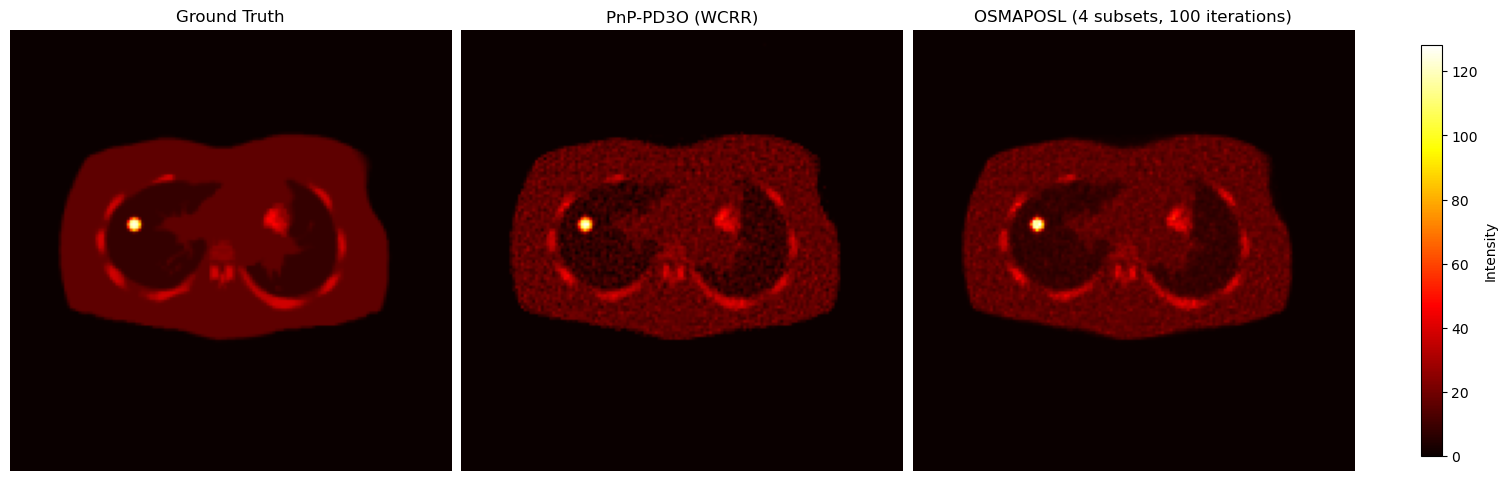

In [8]:
gt_arr = ground_truth.as_array()[0]
pd3o_arr = pd3o.solution.as_array()[0]
osem_arr = osem_recon.as_array()[0]

vmax = max(gt_arr.max(), pd3o_arr.max(), osem_arr.max())
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

axes[0].imshow(gt_arr, cmap="hot", vmin=0, vmax=vmax)
axes[0].set_title('Ground Truth'); axes[0].axis('off')

axes[1].imshow(pd3o_arr, cmap="hot", vmin=0, vmax=vmax)
axes[1].set_title('PnP-PD3O (WCRR)'); axes[1].axis('off')

im = axes[2].imshow(osem_arr, cmap="hot", vmin=0, vmax=vmax)
axes[2].set_title(f'OSMAPOSL ({num_subsets} subsets, {num_subiterations} iterations)'); axes[2].axis('off')

fig.colorbar(im, ax=axes, shrink=0.85, label='Intensity')
plt.show()

---

# 2. PnP-SVRG (DRUNet): Plug-and-Play reconstruction

Plug-and-Play DRUNet PET Reconstruction with SVRG in SIRF

* This section demonstrates how to integrate learned regularization components from DeepInverse into PET reconstruction workflows using SIRF.

* It implements a Plug-and-Play (PnP) reconstruction algorithm using a pretrained DRUNet denoiser as an implicit prior.

* The reconstruction uses Stochastic Variance Reduced Gradient (SVRG) for data fidelity updates combined with iterative denoising steps.

## Simulate acquisition data

In [9]:
# Reusing the same noisy acquired_data and acquisition model for fair comparison.
obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun.set_acquisition_model(acq_model)


## Baseline reconstruction: OSMAPOSL

In [10]:
params = SELECTED_PARAMETERS["OSMAPOSL"]
num_subsets = params["num_subsets"]

recon = pet.OSMAPOSLReconstructor()
recon.set_num_subsets(num_subsets)

initial_image = initial_image.clone()
make_cylindrical_fov(initial_image)


### OSMAPOSL (no prior)

In [11]:
params = SELECTED_PARAMETERS["OSMAPOSL"]
num_subiters = params["num_iterations"]

obj_fun_no_prior = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun_no_prior.set_acquisition_model(acq_model)


In [12]:
recon.set_objective_function(obj_fun_no_prior)
recon.set_num_subiterations(num_subiters)
recon.set_up(initial_image)
recon.set_current_estimate(initial_image)
recon.process()

reconstructed_image_no_prior = recon.get_output()

### OSMAPOSL + RDP

In [13]:
params = SELECTED_PARAMETERS["OSMAPOSL+RDP"]
num_subiters = params["num_iterations"]

prior = pet.RelativeDifferencePrior()
prior.set_penalisation_factor(params["regularization_weight"])
prior.set_gamma(params["gamma"])
prior.set_epsilon(params["epsilon"])
prior.set_kappa(initial_image.get_uniform_copy(1.0))

obj_fun_rdp = pet.make_Poisson_loglikelihood(acquired_data)
obj_fun_rdp.set_acquisition_model(acq_model)
obj_fun_rdp.set_prior(prior)


In [14]:
recon.set_objective_function(obj_fun_rdp)
recon.set_num_subiterations(num_subiters)
recon.set_up(initial_image)
recon.set_current_estimate(initial_image)
recon.process()

reconstructed_image_rdp = recon.get_output()

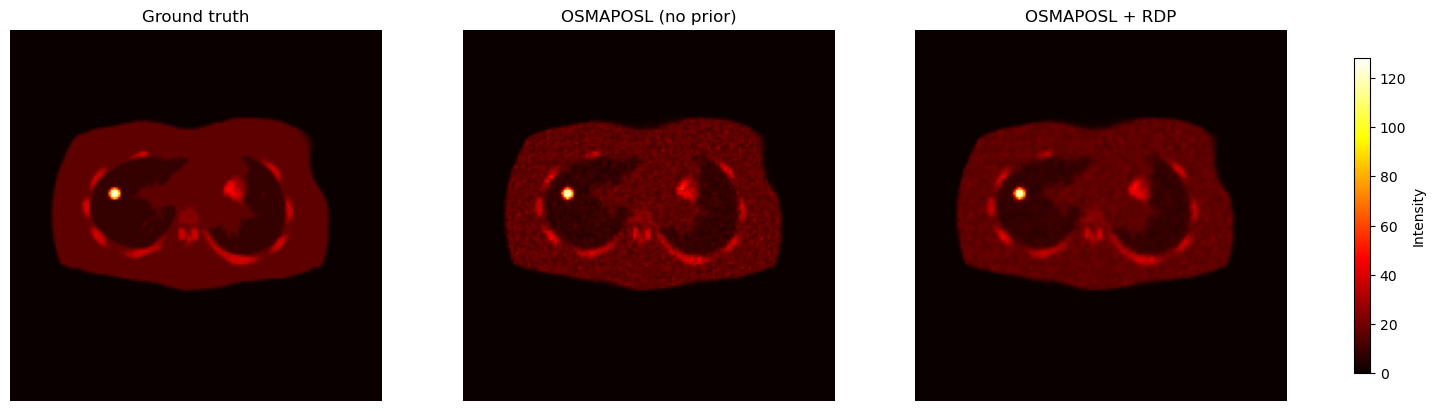

In [15]:
gt_slice = image.as_array()[im_slice, :, :]
no_prior_slice = reconstructed_image_no_prior.as_array()[im_slice, :, :]
rdp_slice = reconstructed_image_rdp.as_array()[im_slice, :, :]

vmin = 0.0
vmax = max(gt_slice.max(), no_prior_slice.max(), rdp_slice.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

im0 = axes[0].imshow(gt_slice, cmap="hot", vmin=vmin, vmax=vmax)
axes[0].set_title("Ground truth")
axes[0].axis("off")

im1 = axes[1].imshow(no_prior_slice, cmap="hot", vmin=vmin, vmax=vmax)
axes[1].set_title("OSMAPOSL (no prior)")
axes[1].axis("off")

im2 = axes[2].imshow(rdp_slice, cmap="hot", vmin=vmin, vmax=vmax)
axes[2].set_title("OSMAPOSL + RDP")
axes[2].axis("off")

cbar = fig.colorbar(im2, ax=axes, shrink=0.85)
cbar.set_label("Intensity")

plt.show()

## Learned denoising with DRUNet

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

denoiser = dinv.models.DRUNet(
    in_channels=1,
    out_channels=1,
    pretrained="download"
).to(device)

denoiser.eval()

Device: cpu


DRUNet(
  (m_head): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (m_down1): Sequential(
    (0): ResBlock(
      (res): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (1): ResBlock(
      (res): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (2): ResBlock(
      (res): Sequential(
        (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): ReLU(inplace=True)
        (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
    (3): ResBlock(
      (res): Sequential(
        (0): Conv2

### Single-step DRUNet denoising on OSMAPOSL (no prior)

In [17]:
slice_no_prior = reconstructed_image_no_prior.as_array()[im_slice, :, :].astype(np.float32)

smin = slice_no_prior.min()
smax = slice_no_prior.max()
slice_norm = (slice_no_prior - smin) / (smax - smin + 1e-8)

x = torch.tensor(slice_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    x_denoised = denoiser(x, sigma=0.05)

slice_denoised = x_denoised.squeeze().detach().cpu().numpy()
slice_denoised = slice_denoised * (smax - smin) + smin

### Slice-wise DRUNet denoising helper

In [18]:
def drunet_denoise_volume_2p5d(vol3d, denoiser, device, sigma=0.05):
    vol_out = np.zeros_like(vol3d, dtype=np.float32)

    for z in range(vol3d.shape[0]):
        slice2d = vol3d[z, :, :].astype(np.float32)

        smin = slice2d.min()
        smax = slice2d.max()
        slice2d_norm = (slice2d - smin) / (smax - smin + 1e-8)

        x = torch.tensor(slice2d_norm, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)

        with torch.no_grad():
            x_denoised = denoiser(x, sigma=sigma)

        out = x_denoised.squeeze().detach().cpu().numpy()
        out = out * (smax - smin) + smin
        vol_out[z, :, :] = out

    return vol_out

## SVRG-based Plug-and-Play reconstruction

### SVRG setup

In [19]:
eps = 1e-6
num_subsets = SELECTED_PARAMETERS["PnP-SVRG (DRUNet)"].get(
    "num_subsets", SELECTED_PARAMETERS["OSMAPOSL"]["num_subsets"]
)

ones_acq = acquired_data.get_uniform_copy(1.0)
sens_img = acq_model.backward(ones_acq)
sens_arr = sens_img.as_array().astype(np.float32)


In [20]:
class STIRSubsetFunction:
    def __init__(self, obj_fun, subset_idx):
        self.obj_fun = obj_fun
        self.subset_idx = subset_idx

    def __call__(self, x):
        return self.obj_fun.value(x)

    def gradient(self, x, out=None):
        g = self.obj_fun.gradient(x, self.subset_idx)
        if out is not None:
            out.fill(g)
            return out
        return g

In [21]:
obj_fun_no_prior.set_up(initial_image)
subset_functions = [STIRSubsetFunction(obj_fun_no_prior, s) for s in range(num_subsets)]

svrg_obj = SVRGFunction(
    subset_functions,
    snapshot_update_interval=num_subsets
)

### SVRG update step

In [22]:
def cil_svrg_step(current_image, alpha=1.0):
    x_arr = current_image.as_array().astype(np.float32)

    grad_img = svrg_obj.gradient(current_image)
    grad_arr = grad_img.as_array().astype(np.float32)

    P = x_arr / (sens_arr + eps)

    x_new = x_arr + alpha * P * grad_arr
    x_new[x_new < 0] = 0

    out = current_image.clone()
    out.fill(x_new)
    make_cylindrical_fov(out)
    return out

## Run the algorithm (PnP reconstruction loop)

In [23]:
params = SELECTED_PARAMETERS["PnP-SVRG (DRUNet)"]

num_pnp_iters = params["num_iterations"]
sigma_denoiser = params["denoiser_strength"]
alpha = params["step_size"]
lam = params["denoiser_blend"]

current_image = initial_image.clone()
obj_fun_no_prior.set_up(current_image)

pnp_objective_values = [obj_fun_no_prior.value(current_image)]

all_pnp_images = np.ndarray(
    shape=(num_pnp_iters + 1,) + current_image.as_array().shape,
    dtype=np.float32,
)
all_pnp_images[0] = current_image.as_array()


In [24]:
for i in range(1, num_pnp_iters + 1):
    current_image = cil_svrg_step(current_image, alpha=alpha)
    
    # DRUNet denoising every iteration
    if i % 1 == 0:
        vol = current_image.as_array().astype(np.float32)
        vol_denoised = drunet_denoise_volume_2p5d(
            vol, denoiser, device, sigma=sigma_denoiser
        )

         # soft blending to reduce oversmoothing
        vol = (1 - lam) * vol + lam * vol_denoised
        vol = make_positive(vol)

        current_image.fill(vol)
        make_cylindrical_fov(current_image)

    pnp_objective_values.append(obj_fun_no_prior.value(current_image))
    all_pnp_images[i] = current_image.as_array()

## Comparison of reconstruction methods

We compare different reconstruction strategies:

* **OSMAPOSL (no prior)**: Standard iterative reconstruction without regularization  
* **OSMAPOSL + RDP**: Reconstruction with Relative Difference Prior (classical regularization)  
* **DRUNet (single-step, no prior)**: Post-processing denoising applied once to OSMAPOSL (no prior) output 
* **PnP (SVRG + DRUNet)**: Iterative Plug-and-Play reconstruction combining SVRG data consistency with DRUNet denoising  

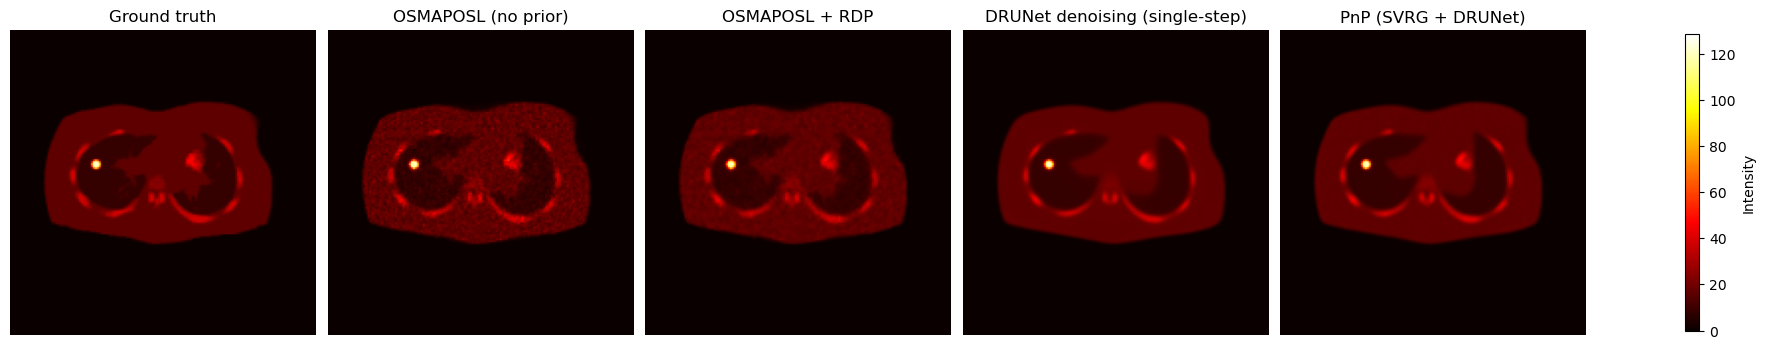

In [25]:
gt_slice = image.as_array()[im_slice, :, :]
no_prior_slice = reconstructed_image_no_prior.as_array()[im_slice, :, :]
rdp_slice = reconstructed_image_rdp.as_array()[im_slice, :, :]
drunet_once_slice = slice_denoised 
final_pnp = all_pnp_images[-1, im_slice, :, :]

plt.figure(figsize=(20,4))

plt.subplot(1,5,1)
plt.imshow(gt_slice, cmap="hot", vmin=vmin, vmax=vmax)
plt.title("Ground truth")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(no_prior_slice, cmap="hot", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL (no prior)")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(rdp_slice, cmap="hot", vmin=vmin, vmax=vmax)
plt.title("OSMAPOSL + RDP")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(drunet_once_slice, cmap="hot", vmin=vmin, vmax=vmax)
plt.title("DRUNet denoising (single-step)")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(final_pnp, cmap="hot", vmin=vmin, vmax=vmax)
plt.title("PnP (SVRG + DRUNet)")
plt.axis("off")

plt.tight_layout()
cbar = plt.colorbar(ax=plt.gcf().axes, shrink=0.8)
cbar.set_label("Intensity")
plt.show()


---

# 3. PnP-HQS (DRUNet): Plug-and-Play reconstruction

Implementing Plug-and-play DRUNet regularization from DeepInverse with Half Quadratic Splitting in STIR
This notebook implements a Half Quadratic Splitting algorithm for PET image reconstruction, using tomographic reconstruction components from SIRF, and wrapping learned regularization components from DeepInverse to be compatible with SIRF's optimization routines.

## Set up data fidelity operator with STIR

In [26]:
f = KullbackLeibler(b=acquired_data, eta=(acquired_data * 0 + 1e-5))
K = acq_model
normK = K.norm()

## Set up hyperparameters

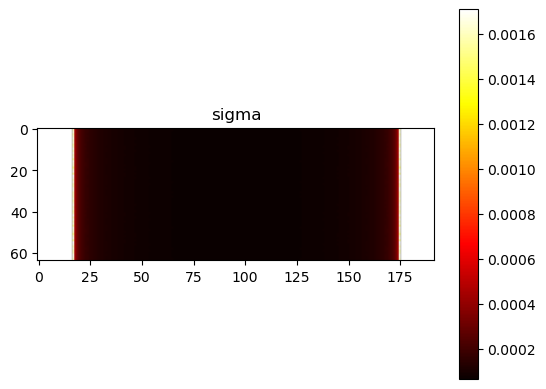

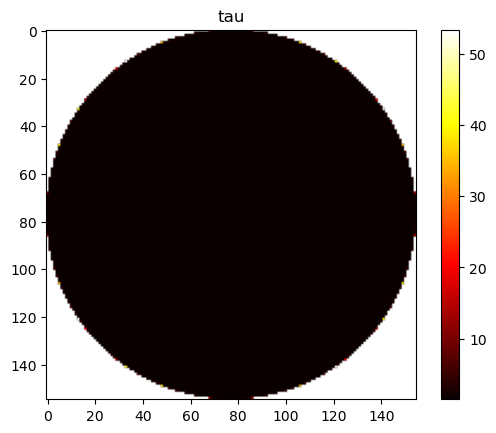

In [27]:
params = SELECTED_PARAMETERS["PnP-HQS (DRUNet)"]
regularization_weight = params["regularization_weight"]

ones_image = ground_truth.get_uniform_copy(1.0)
ones_data = acquired_data.get_uniform_copy(1.0)

gamma = regularization_weight

sigma = gamma * ones_data / acq_model.get_linear_acquisition_model().forward(ones_image)
tau = (1.0 / gamma) * ones_image / acq_model.backward(ones_data)

plt.imshow(sigma.as_array()[0, 0, :, :], cmap="hot")
plt.colorbar()
plt.title("sigma")
plt.show()

plt.imshow(tau.as_array()[0, :, :], cmap="hot")
plt.colorbar()
plt.title("tau")
plt.show()


## Implement Plug-and-play DRUNET wrapper for CIL/SIRF/STIR images 

In [28]:
class DRUNetPnP(Function):
    """
    Plug-and-play DRUNet wrapper for CIL/SIRF/STIR images with shape (1, H, W).
    Must implement the `__call__`, `gradient` and `proximal` function signatures.
    Only `proximal` is used by the PDHG algorithm.
    """
    def __init__(
        self,
        model=None,
        device=None,
        sigma=3.0 / 255.0,  # DRUNet normalized noise level
        clamp=True,      # clamp normalized image to [0,1] before/after denoising
        eps=1e-12,
    ):
        super().__init__()

        self.device = torch.device(
            device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")
        )

        # Initialize the denoising model from DeepInverse, and implement it as an equivariant denoiser
        self.model = DRUNet(pretrained="download", in_channels=1, out_channels=1) if model is None else model
        self.model = EquivariantDenoiser(self.model)
        self.model.eval()
        self.model.to(self.device)

        self._sigma = float(sigma)
        self.clamp = bool(clamp)
        self.eps = float(eps)

    def __call__(self, x):
        # PnP prior: no associated scalar functional
        return 0.0

    def gradient(self, x, out=None):
        raise NotImplementedError("DRUNet PnP wrapper does not provide a gradient.")

    def proximal(self, x, tau, out=None):
        """ proximal(x, tau):
        1. x -> numpy
        2. normalize by max(x)
        3. denoise with DRUNet
        4. scale back by max(x)
        5. return DataContainer """

        if out is not None:
            xout = out.as_array()

        arr = x.asarray().astype(np.float32, copy=True)
        arr = np.nan_to_num(arr)

        if arr.ndim != 3 or arr.shape[0] != 1:
            raise ValueError(
                f"Expected image shape (1, H, W), got {arr.shape}"
            )

        # arr shape: (1, H, W)
        xmax = float(arr.max())

        if xmax <= self.eps:
            out.fill(arr)
            return out

        arr_norm = arr / xmax

        if self.clamp:
            arr_norm = np.clip(arr_norm, 0.0, 1.0)

        # DRUNet input: (N, C, H, W) = (1, 1, H, W)
        xt = torch.from_numpy(arr_norm).unsqueeze(0).to(self.device)
        sigma_t = self._sigma

        with torch.no_grad():
            den = self.model(xt, sigma_t)

        den = den.squeeze(0).detach().cpu().numpy()   # back to (1, H, W)

        if self.clamp:
            den = np.clip(den, 0.0, 1.0)

        den = den * xmax
        out.fill(den.astype(arr.dtype, copy=False))
        make_cylindrical_fov(out)
        return out

## Run the algorithm

  0%|          | 0/50 [00:00<?, ?it/s]

applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...ok
no additive term added
no unnormalisation applied
no background term added
backprojecting...

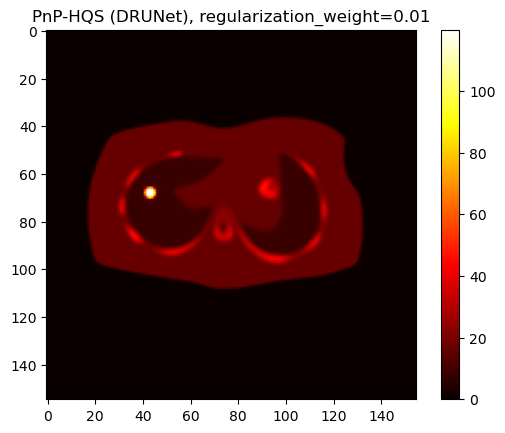

In [30]:
params = SELECTED_PARAMETERS["PnP-HQS (DRUNet)"]
num_iterations = params["num_iterations"]
regularization_weight = params["regularization_weight"]
denoiser_strength = params["denoiser_strength"]

gamma = regularization_weight
sigma = gamma * ones_data / acq_model.get_linear_acquisition_model().forward(ones_image)
tau = (1.0 / gamma) * ones_image / acq_model.backward(ones_data)

g = DRUNetPnP(
    sigma=denoiser_strength,
    clamp=True,
)

def do_nothing(self):
    return 0.0

setattr(PDHG, 'update_objective', do_nothing)

pdhg = PDHG(
    f=f,
    g=g,
    operator=K,
    sigma=sigma,
    tau=tau,
    update_objective_interval=4,
    check_convergence=False,
)

pdhg.run(num_iterations)

pdhg_recon = pdhg.get_output()

plt.imshow(pdhg_recon.as_array()[0, :, :], cmap="hot")
plt.colorbar()
plt.title(f"PnP-HQS (DRUNet), regularization_weight={regularization_weight}")
plt.show()


## Compare to conventional OSMAPOSL reconstruction

In [31]:
if "recon_osmaposl" in globals():
    osem_recon = recon_osmaposl
else:
    params = SELECTED_PARAMETERS["OSMAPOSL"]
    num_subsets = params["num_subsets"]
    num_subiterations = params["num_iterations"]

    osem_obj_fun = pet.make_Poisson_loglikelihood(acquired_data)
    osem_obj_fun.set_acquisition_model(acq_model)

    osem = pet.OSMAPOSLReconstructor()
    osem.set_objective_function(osem_obj_fun)
    osem.set_num_subsets(num_subsets)
    osem.set_num_subiterations(num_subiterations)
    osem.set_current_estimate(initial_image.clone())
    osem.set_up(initial_image.clone())
    osem.process()
    osem_recon = osem.get_output()
    recon_osmaposl = osem_recon


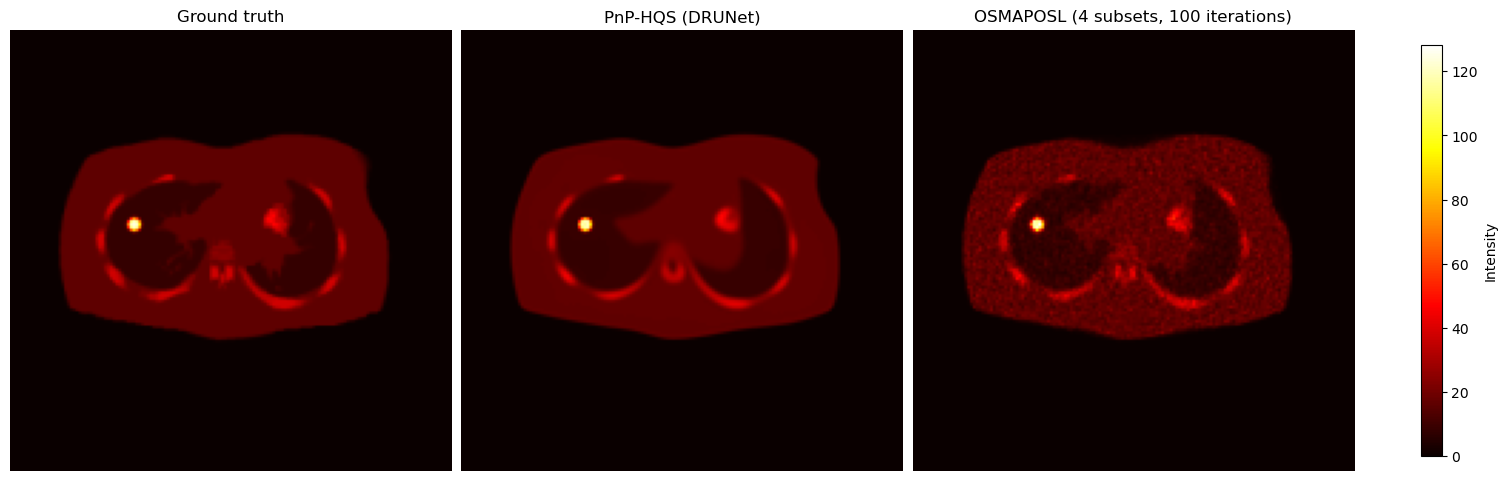

In [32]:
# --- comparison plot with matched scaling ---
# arrays
gt_arr = ground_truth.as_array()[0, :, :]
pnp_arr = pdhg_recon.as_array()[0, :, :]
osem_arr = osem_recon.as_array()[0, :, :]

# common scaling
vmin = 0.0
vmax = max(gt_arr.max(), pnp_arr.max(), osem_arr.max())

cmap = "hot"

fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

im0 = axes[0].imshow(gt_arr, cmap=cmap, vmin=vmin, vmax=vmax)
axes[0].set_title('Ground truth')
axes[0].axis('off')

im1 = axes[1].imshow(pnp_arr, cmap=cmap, vmin=vmin, vmax=vmax)
axes[1].set_title('PnP-HQS (DRUNet)')
axes[1].axis('off')

im2 = axes[2].imshow(osem_arr, cmap=cmap, vmin=vmin, vmax=vmax)
axes[2].set_title(f'OSMAPOSL ({num_subsets} subsets, {num_subiterations} iterations)')
axes[2].axis('off')

cbar = fig.colorbar(im2, ax=axes, shrink=0.85)
cbar.set_label('Intensity')

plt.show()

In [33]:
# Standardized final reconstruction variable names used by the evaluation cell.
recon_osmaposl = globals().get("reconstructed_image_no_prior", globals().get("osem_recon", None))
recon_rdp = globals().get("reconstructed_image_rdp", None)
recon_pd3o = pd3o.solution if "pd3o" in globals() else globals().get("pd3o_recon", None)
recon_svrg = globals().get("current_image", globals().get("svrg_recon", None))
recon_hqs = globals().get("pdhg_recon", globals().get("hqs_recon", None))


# Final Qualitative and Quantitative Evaluation

Method               | PSNR   | SSIM   | MAE     | SNR   
------------------------------------------------------------
OSMAPOSL             | 39.52  | 0.9495 | 1.835   | 37.29 
OSMAPOSL+RDP         | 43.09  | 0.9778 | 1.161   | 35.02 
PnP-PD3O (WCRR)      | 37.08  | 0.9167 | 2.526   | 35.11 
PnP-SVRG (DRUNet)    | 45.90  | 0.9913 | 0.617   | 30.77 
PnP-HQS (DRUNet)     | 45.07  | 0.9919 | 0.538   | 42.53 


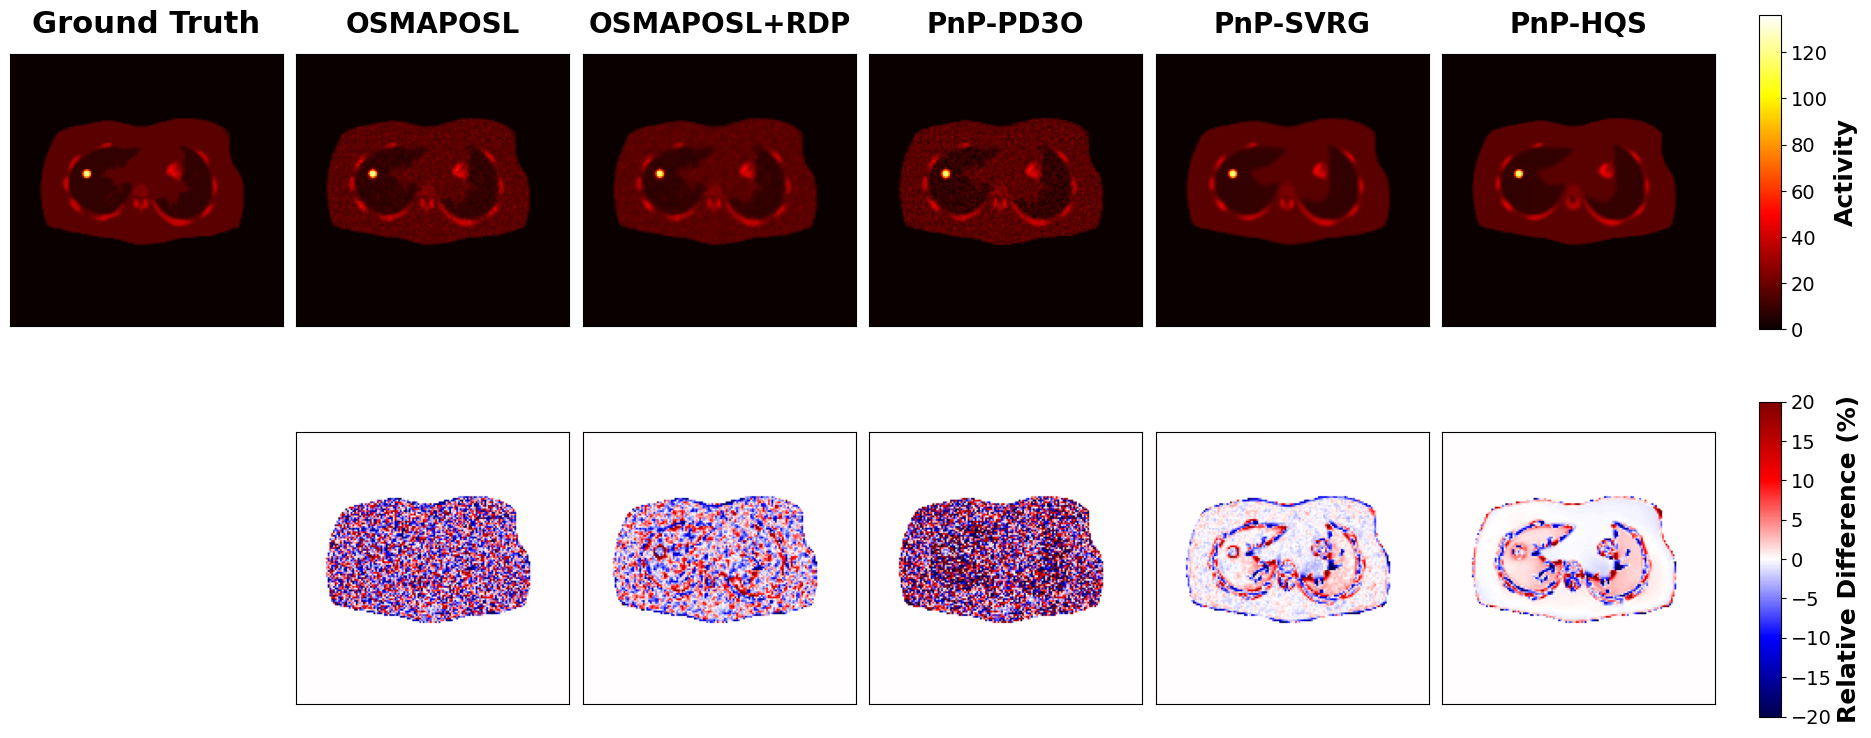

In [34]:
fig_slice = globals().get("im_slice", None)

gt = _to_numpy_2d(ground_truth, fig_slice)

recons = {
    "OSMAPOSL": _to_numpy_2d(recon_osmaposl, fig_slice),
    "OSMAPOSL+RDP": _to_numpy_2d(recon_rdp, fig_slice),
    "PnP-PD3O (WCRR)": _to_numpy_2d(recon_pd3o, fig_slice),
    "PnP-SVRG (DRUNet)": _to_numpy_2d(recon_svrg, fig_slice),
    "PnP-HQS (DRUNet)": _to_numpy_2d(recon_hqs, fig_slice),
}

missing = [name for name, arr in {"Ground Truth": gt, **recons}.items() if arr is None]
if missing:
    raise RuntimeError(
        "Missing result arrays for: "
        + ", ".join(missing)
        + ". Please run all reconstruction sections before this evaluation cell."
    )

body = gt > gt.max() * 0.05
noise = ~body
eps = gt.max() * 0.05

print(f"{'Method':<20} | {'PSNR':<6} | {'SSIM':<6} | {'MAE':<7} | {'SNR':<6}")
print("-" * 60)

error_maps = {}

for name, img in recons.items():
    img_n = (img - img.min()) / (img.max() - img.min() + 1e-8)
    gt_n = (gt - gt.min()) / (gt.max() - gt.min() + 1e-8)

    p = psnr(gt_n, img_n, data_range=1.0)
    s = ssim(gt_n, img_n, data_range=1.0)
    mae = np.mean(np.abs(img[body] - gt[body]))
    snr = np.mean(img[body]) / (np.std(img[noise]) + 1e-8)

    print(f"{name:<20} | {p:<6.2f} | {s:<6.4f} | {mae:<7.3f} | {snr:<6.2f}")

    error_maps[name] = np.nan_to_num(((img - gt) / (gt + eps)) * 100) * body


fig, axes = plt.subplots(2, 6, figsize=(22, 9))
plt.subplots_adjust(wspace=0.05, hspace=0.2)

vmax = gt.max() * 1.1

full_methods = list(recons.keys())
short_methods = ["OSMAPOSL", "OSMAPOSL+RDP", "PnP-PD3O", "PnP-SVRG", "PnP-HQS"]

axes[0, 0].imshow(gt * body, cmap="hot", vmin=0, vmax=vmax)
axes[0, 0].set_title("Ground Truth", fontsize=22, fontweight="bold", pad=15)

for i, name in enumerate(full_methods):
    axes[0, i + 1].imshow(recons[name] * body, cmap="hot", vmin=0, vmax=vmax)
    axes[0, i + 1].set_title(short_methods[i], fontsize=20, fontweight="bold", pad=15)

axes[1, 0].axis("off")

for i, name in enumerate(full_methods):
    im_err = axes[1, i + 1].imshow(error_maps[name], cmap="seismic", vmin=-20, vmax=20)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

cax1 = fig.add_axes([0.92, 0.55, 0.01, 0.35])
cb1 = fig.colorbar(axes[0, 0].images[0], cax=cax1)
cb1.set_label("Activity", fontsize=18, fontweight="bold")
cb1.ax.tick_params(labelsize=14)

cax2 = fig.add_axes([0.92, 0.12, 0.01, 0.35])
cb2 = fig.colorbar(im_err, cax=cax2)
cb2.set_label("Relative Difference (%)", fontsize=18, fontweight="bold")
cb2.ax.tick_params(labelsize=14)

plt.show()
